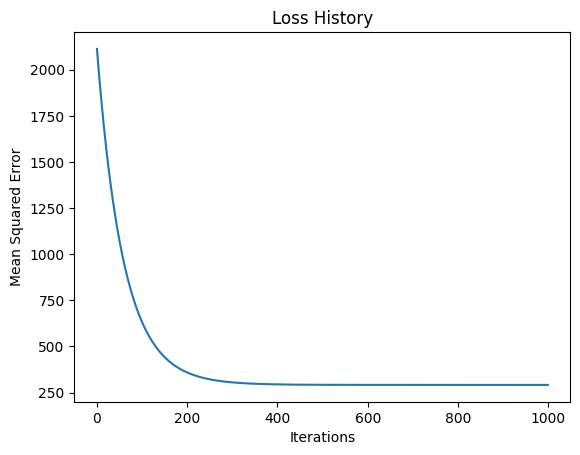

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegression:
    # We initialize the model learning rate, number of iterations, weights, bias, and loss history to understand how the model learns over time.
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    # The fit method here is the main training loop for the linear regression model with data X and target values y.
    # The main equation for linear regression is y_bar = Xw + b, where X is the input data, w is weights, and b is the bias.
    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        # The linear regression loss function is the mean squared error (MSE), which measured the average of the squares of the errors between predicted and actual values.
        # The MSE equation is MSE = (1/n) * sigma((y_predicted - y_actual)^2), where n is the number of samples, y_predicted is the predicted value from the model, and y_actual is the true value from the dataset.
        # Now, the training loop iteratively updates the weights and bias to minimize the MSE loss function using gradient descent.
        for _ in range(self.n_iterations):
            # Forward pass: Calculate predictions
            y_predicted = np.dot(X, self.weights) + self.bias

            # Calculate the error vector
            error = y_predicted - y

            mse = (1 / n_samples) * np.dot(error, error)
            self.loss_history.append(mse)

            # Calculate gradients
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    # After training the model using fit method within the definediterations and learning step, we will have the final weights and bias that best fit for the given data.
    def predict(self, X):
        y_predicted = np.dot(X, self.weights) + self.bias
        return y_predicted
    
    # We can also visualize the loss history to see how the model converges over time.
    def plot_loss(self):
        plt.plot(self.loss_history)
        plt.xlabel('Iterations')
        plt.ylabel('Mean Squared Error')
        plt.title('Loss History')
        plt.show()

class __main__():
    # Example usage
    from sklearn.model_selection import train_test_split
    from sklearn.datasets import make_regression

    # Create synthetic data for regression
    X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train the linear regression model
    model = LinearRegression(learning_rate=0.01, n_iterations=1000)
    model.fit(X_train, y_train)

    # Predict on the test set
    predictions = model.predict(X_test)

    # Plot the loss history
    model.plot_loss()

    # In case of polynomial regression, we can generate data that has a non-linear relationship between the features and the target variable. 
    # For example we will create a quadratiic relationship between the input and output.
    X_poly = np.hstack((X, X**2))

    # Then we can train the polynomial regression model using the same LinearRegression class, but with the polynomial features as input.